<a href="https://colab.research.google.com/github/bro670/G-139/blob/main/LOGISTICS_ANALYSIS_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel("National_Logistics_Dataset_V2_50000_realistic_final_v2.xlsx")

In [ ]:
# ============================================
# DATASET SHAPE
# ============================================

print("Dataset Shape:")
print(df.shape)
# ============================================
# FIRST & LAST RECORDS
# ============================================

print("First 5 Records")
display(df.head())

print("Last 5 Records")
display(df.tail())
# ============================================
# COLUMN NAMES
# ============================================
print("Columns in Dataset:\n")

for col in df.columns:
    print(col)
# ============================================
# DATA TYPES
# ============================================
print(df.dtypes)
# ============================================
# DATASET INFORMATION
# ============================================

df.info()
# ============================================
# MISSING VALUES
# ============================================

missing = df.isnull().sum()

print("Missing Values:\n")
print(missing)
# ============================================
# DUPLICATE RECORDS
# ============================================

duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Dataset Shape:
(50000, 32)
First 5 Records


,Shipment_ID,Shipment_Date,Company,Status,Origin_Country,Origin_City,Destination_Country,Destination_City,Cargo_Type,Industry,...,Customs,Freight_Cost,Fuel_Cost,Insurance_Cost,Total_Cost,Revenue,Profit,CO2_kg,Priority,Trade_Type
0,SHP0000001,2024-04-12,CMA CGM,Delivered,Japan,Tokyo,India,Mumbai,Pharmaceuticals,Pharma,...,Yes,12556.01,4782.67,1445.41,18784.09,37753.17,18969.08,58.46,Critical,Import
1,SHP0000002,2025-03-11,DHL,Delivered,South Korea,Seoul,India,Bengaluru,Textiles,Textile,...,Yes,74083.40,27464.78,133.51,101681.68,147968.29,46286.60,357.38,Standard,Import
2,SHP0000003,2026-05-10,Blue Dart,Delivered,Australia,Sydney,India,Hyderabad,Food,Food,...,Yes,169645.35,61357.08,259.03,231261.46,311843.53,80582.07,790.73,Standard,Import
3,SHP0000004,2024-09-27,UPS,Delayed,UK,London,India,Chennai,Food,Food,...,Yes,402308.39,169279.76,64.13,571652.28,1054063.96,482411.68,6720.49,Critical,Import
4,SHP0000005,2024-04-16,Delhivery,Delivered,India,Hyderabad,Brazil,Sao Paulo,Steel,Heavy,...,Yes,655300.39,255206.70,87.36,910594.46,1279184.19,368589.73,3622.61,Standard,Export


Last 5 Records


,Shipment_ID,Shipment_Date,Company,Status,Origin_Country,Origin_City,Destination_Country,Destination_City,Cargo_Type,Industry,...,Customs,Freight_Cost,Fuel_Cost,Insurance_Cost,Total_Cost,Revenue,Profit,CO2_kg,Priority,Trade_Type
49995,SHP0049996,2026-02-16,Kuehne + Nagel,Delivered,India,Kolkata,Singapore,Singapore,Chemicals,Chemical,...,Yes,71124.26,26745.82,101.85,97971.93,139413.29,41441.36,377.85,Standard,Export
49996,SHP0049997,2025-08-12,Blue Dart,Delivered,India,Ahmedabad,Singapore,Singapore,Pharmaceuticals,Pharma,...,Yes,11273.88,4268.17,666.91,16208.96,22400.56,6191.60,56.36,Standard,Export
49997,SHP0049998,2024-02-05,Emirates SkyCargo,Delivered,India,Bengaluru,Singapore,Singapore,Machinery,Manufacturing,...,Yes,536105.48,230791.39,596.72,767493.59,1355222.84,587729.25,8996.58,Critical,Export
49998,SHP0049999,2024-07-20,Delhivery,Delivered,India,Bengaluru,Singapore,Singapore,Chemicals,Chemical,...,Yes,151169.95,58471.55,305.83,209947.33,409416.64,199469.31,748.31,Critical,Export
49999,SHP0050000,2026-04-03,CMA CGM,Delivered,India,Hyderabad,UK,London,Pharmaceuticals,Pharma,...,Yes,1417.23,565.33,83.17,2065.73,3395.46,1329.73,7.10,Express,Export


Columns in Dataset:

Shipment_ID
Shipment_Date
Company
Status
Origin_Country
Origin_City
Destination_Country
Destination_City
Cargo_Type
Industry
Weight_kg
Cargo_Value_USD
Transport_Mode
Leg1
Leg2
Leg3
Distance_km
Planned_Days
Actual_Days
Delay_Hours
Delay_Reason
Weather
Customs
Freight_Cost
Fuel_Cost
Insurance_Cost
Total_Cost
Revenue
Profit
CO2_kg
Priority
Trade_Type
Shipment_ID             object
Shipment_Date           object
Company                 object
Status                  object
Origin_Country          object
Origin_City             object
Destination_Country     object
Destination_City        object
Cargo_Type              object
Industry                object
Weight_kg              float64
Cargo_Value_USD        float64
Transport_Mode          object
Leg1                    object
Leg2                    object
Leg3                   float64
Distance_km              int64
Planned_Days             int64
Actual_Days              int64
Delay_Hours              int64
Delay_Rea

In [ ]:
df["Shipment_Date"] = pd.to_datetime(df["Shipment_Date"])

# Extract useful information
df["Year"] = df["Shipment_Date"].dt.year
df["Month"] = df["Shipment_Date"].dt.month_name()
df["Month_Number"] = df["Shipment_Date"].dt.month
df["Quarter"] = df["Shipment_Date"].dt.quarter
df["Day_of_Week"] = df["Shipment_Date"].dt.day_name()

In [ ]:
# def add_value_labels(ax, horizontal=False):
#     if horizontal:
#         for container in ax.containers:
#             ax.bar_label(container, fmt='%d', padding=3, fontsize=9, fontweight='bold')
#     else:
#         for container in ax.containers:
#             ax.bar_label(container, fmt='%d', padding=3, fontsize=9, fontweight='bold')

In [ ]:
# Create a complete shipment route
df["Route"] = (
    df["Origin_City"] +
    " → " +
    df["Destination_City"]
)

# Preview the new columns
df[["Shipment_Date", "Month", "Quarter", "Route"]].head()

,Shipment_Date,Month,Quarter,Route
0,2024-04-12,April,2,Tokyo → Mumbai
1,2025-03-11,March,1,Seoul → Bengaluru
2,2026-05-10,May,2,Sydney → Hyderabad
3,2024-09-27,September,3,London → Chennai
4,2024-04-16,April,2,Hyderabad → Sao Paulo


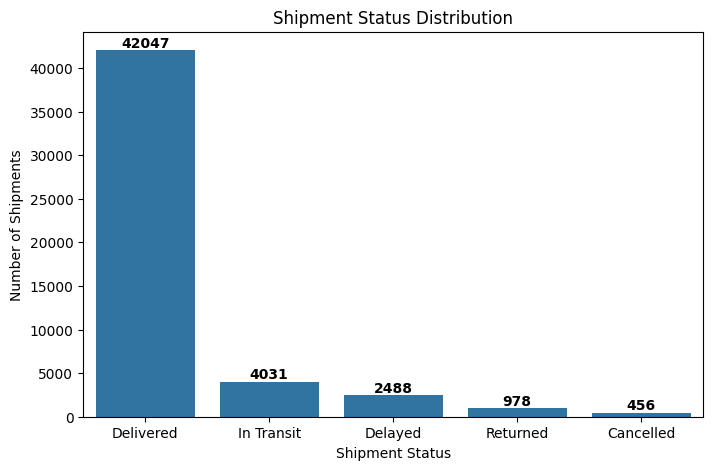

In [ ]:
status_count = df["Status"].value_counts()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=status_count.index,
    y=status_count.values
)

# Add values on bars
for i, value in enumerate(status_count.values):
    ax.text(
        i,
        value + 10,
        str(value),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title("Shipment Status Distribution")
plt.xlabel("Shipment Status")
plt.ylabel("Number of Shipments")

plt.show()

Delay_Reason
Port Congestion    517
Traffic            504
Weather            503
Customs            494
Mechanical         470
Name: count, dtype: int64


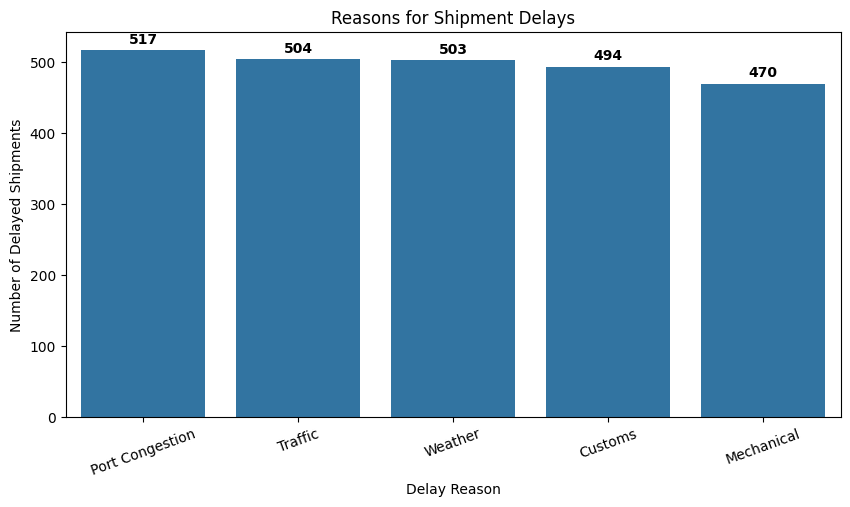

In [ ]:
#--------------------------
# DELAY REASON DISTRIBUTION
#--------------------------

delayed_shipments = df[df["Status"] == "Delayed"]

delay_reason_count = delayed_shipments["Delay_Reason"].value_counts()

print(delay_reason_count)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=delay_reason_count.index,
    y=delay_reason_count.values
)

# Add values on bars
for i, value in enumerate(delay_reason_count.values):
    ax.text(
        i,
        value + 5,
        str(value),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title("Reasons for Shipment Delays")
plt.xlabel("Delay Reason")
plt.ylabel("Number of Delayed Shipments")

plt.xticks(rotation=20)

plt.show()

/tmp/ipykernel_3673/3161914233.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delayed_shipments["Delay_Range"] = pd.cut(


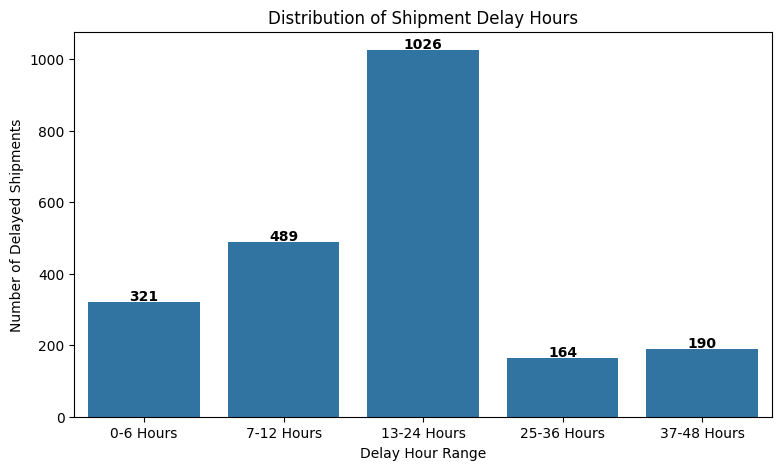

In [ ]:
# ============================================
# DELAY HOUR RANGE DISTRIBUTION (2503 shipments)
# ============================================

delay_bins = [0, 6, 12, 24, 36, 48]

delay_labels = [
    "0-6 Hours",
    "7-12 Hours",
    "13-24 Hours",
    "25-36 Hours",
    "37-48 Hours"
]

delayed_shipments["Delay_Range"] = pd.cut(
    delayed_shipments["Delay_Hours"],
    bins=delay_bins,
    labels=delay_labels,
    include_lowest=True
)

delay_range_count = delayed_shipments["Delay_Range"].value_counts().sort_index()

plt.figure(figsize=(9,5))

ax = sns.barplot(
    x=delay_range_count.index,
    y=delay_range_count.values
)

# Add exact values on bars
for i, value in enumerate(delay_range_count.values):
    ax.text(
        i,
        value + 5,
        str(value),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Distribution of Shipment Delay Hours")
plt.xlabel("Delay Hour Range")
plt.ylabel("Number of Delayed Shipments")

plt.show()

#5.01 % shipments delayed

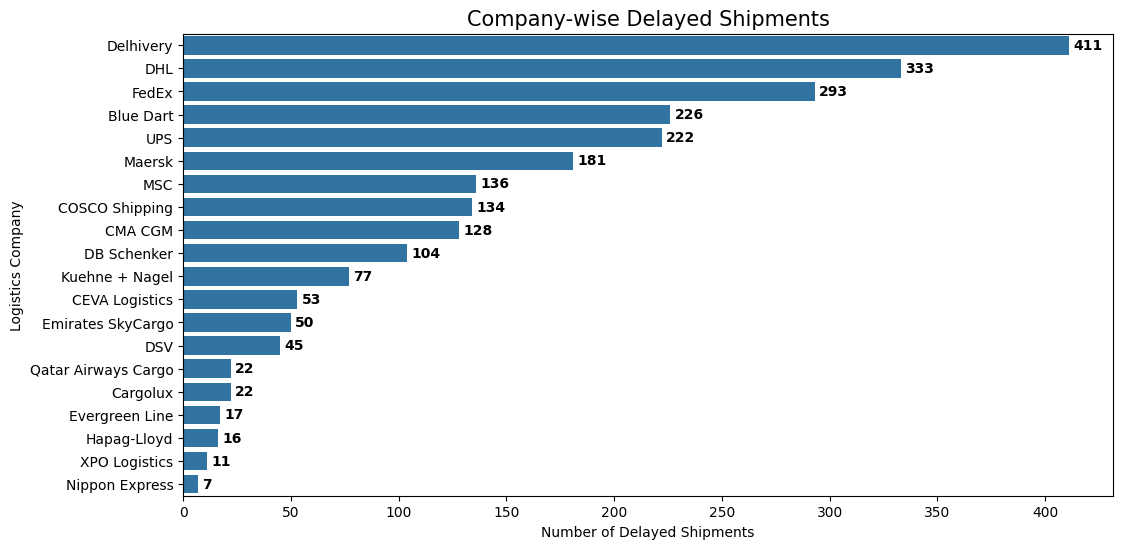

In [ ]:
# ============================================
# COMPANY-WISE DELAYED SHIPMENTS
# ============================================

company_delay = (
    delayed_shipments["Company"]
    .value_counts()
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    y=company_delay.index,
    x=company_delay.values
)

# Display exact values
for i, value in enumerate(company_delay.values):
    ax.text(
        value + 2,
        i,
        str(value),
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Company-wise Delayed Shipments", fontsize=15)
plt.xlabel("Number of Delayed Shipments")
plt.ylabel("Logistics Company")

plt.show()

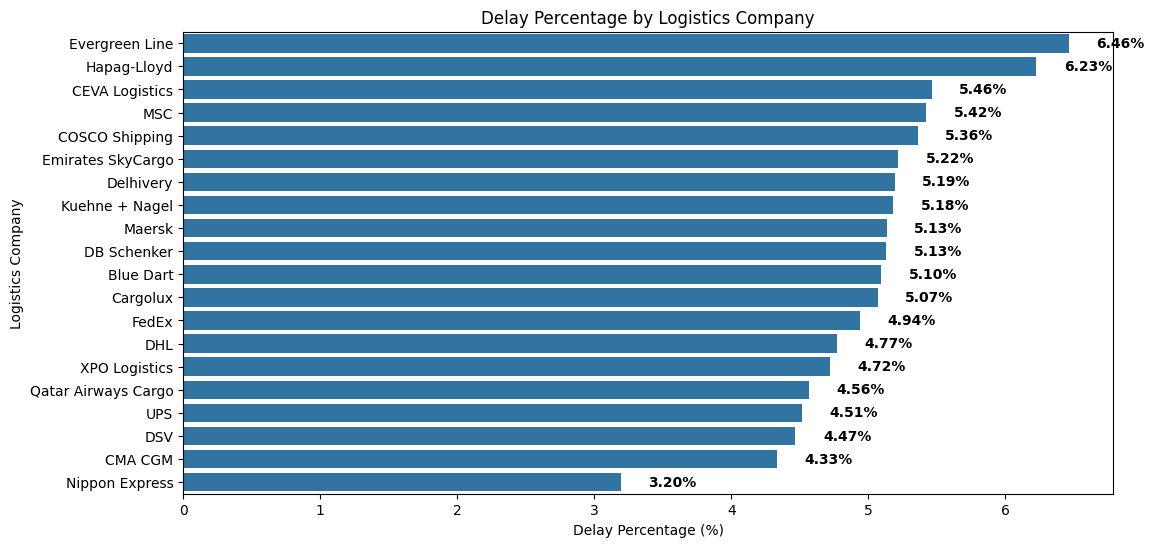

In [ ]:
# ============================================
# DELAY PERCENTAGE BY COMPANY
# ============================================

# Total shipments handled by each company
total_shipments = df["Company"].value_counts()

# Delayed shipments handled by each company
delayed_counts = delayed_shipments["Company"].value_counts()

# Create a comparison table
delay_percentage = (
    (delayed_counts / total_shipments) * 100
).fillna(0)

# Sort values
delay_percentage = delay_percentage.sort_values(ascending=False)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=delay_percentage.values,
    y=delay_percentage.index
)

# Add percentage labels
for i, value in enumerate(delay_percentage.values):
    ax.text(
        value + 0.2,
        i,
        f"{value:.2f}%",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Delay Percentage by Logistics Company")
plt.xlabel("Delay Percentage (%)")
plt.ylabel("Logistics Company")

plt.show()

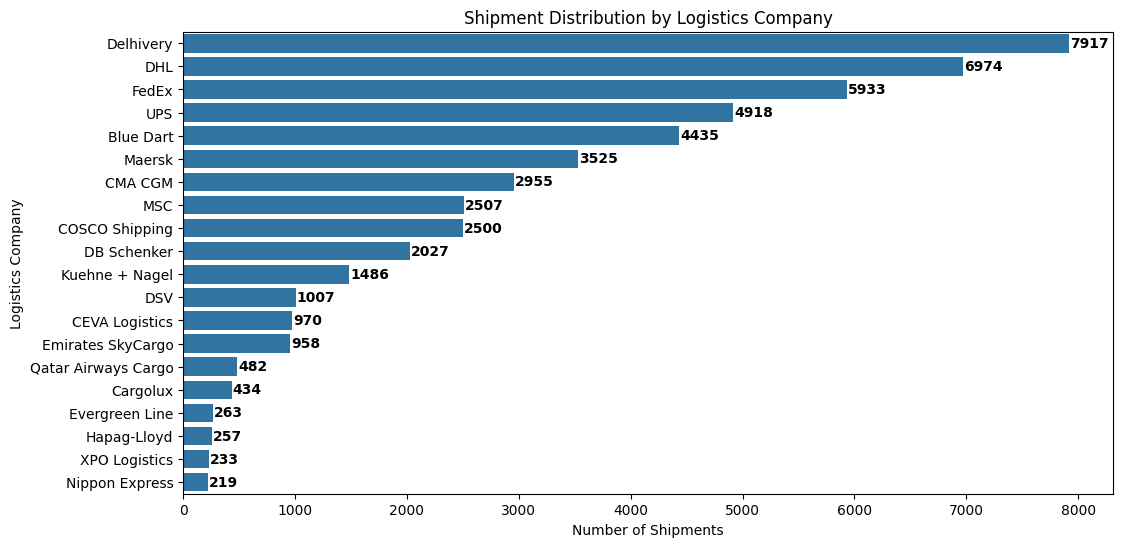

In [ ]:
# ============================================
# COMPANY DISTRIBUTION
# ============================================

company_count = df["Company"].value_counts()

plt.figure(figsize=(12,6))

ax = sns.barplot(
    y=company_count.index,
    x=company_count.values
)

# Display exact values
for i, value in enumerate(company_count.values):
    ax.text(
        value + 10,
        i,
        str(value),
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Shipment Distribution by Logistics Company")
plt.xlabel("Number of Shipments")
plt.ylabel("Logistics Company")

plt.show()

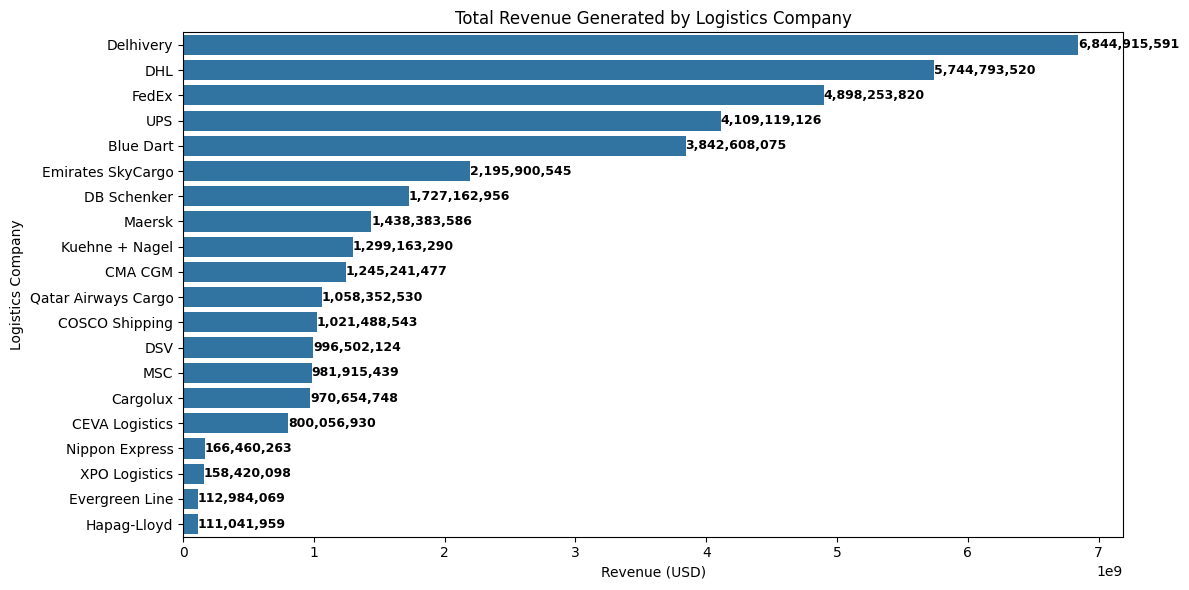

In [ ]:
# ============================================
# REVENUE BY LOGISTICS COMPANY
# ============================================

company_revenue = (
    df.groupby("Company")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=company_revenue.values,
    y=company_revenue.index
)

# Display values
for i, value in enumerate(company_revenue.values):
    ax.text(
        value,
        i,
        f"{value:,.0f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Total Revenue Generated by Logistics Company")
plt.xlabel("Revenue (USD)")
plt.ylabel("Logistics Company")

plt.tight_layout()
plt.show()

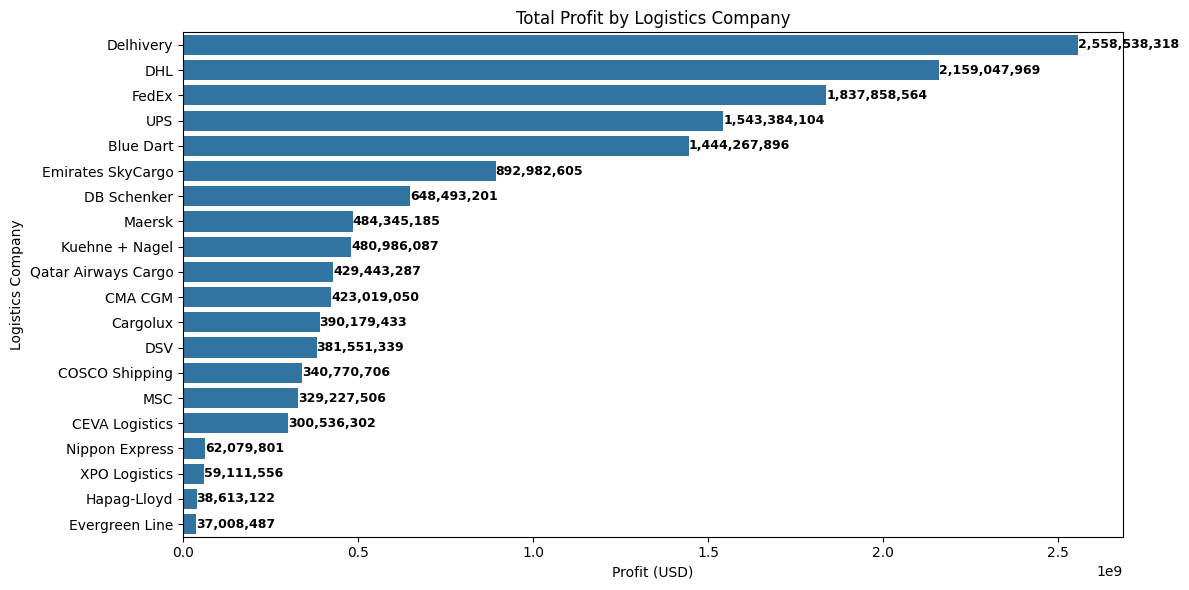

In [ ]:
# ============================================
# PROFIT BY LOGISTICS COMPANY
# ============================================

company_profit = (
    df.groupby("Company")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=company_profit.values,
    y=company_profit.index
)

# Display values
for i, value in enumerate(company_profit.values):
    ax.text(
        value,
        i,
        f"{value:,.0f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Total Profit by Logistics Company")
plt.xlabel("Profit (USD)")
plt.ylabel("Logistics Company")

plt.tight_layout()
plt.show()

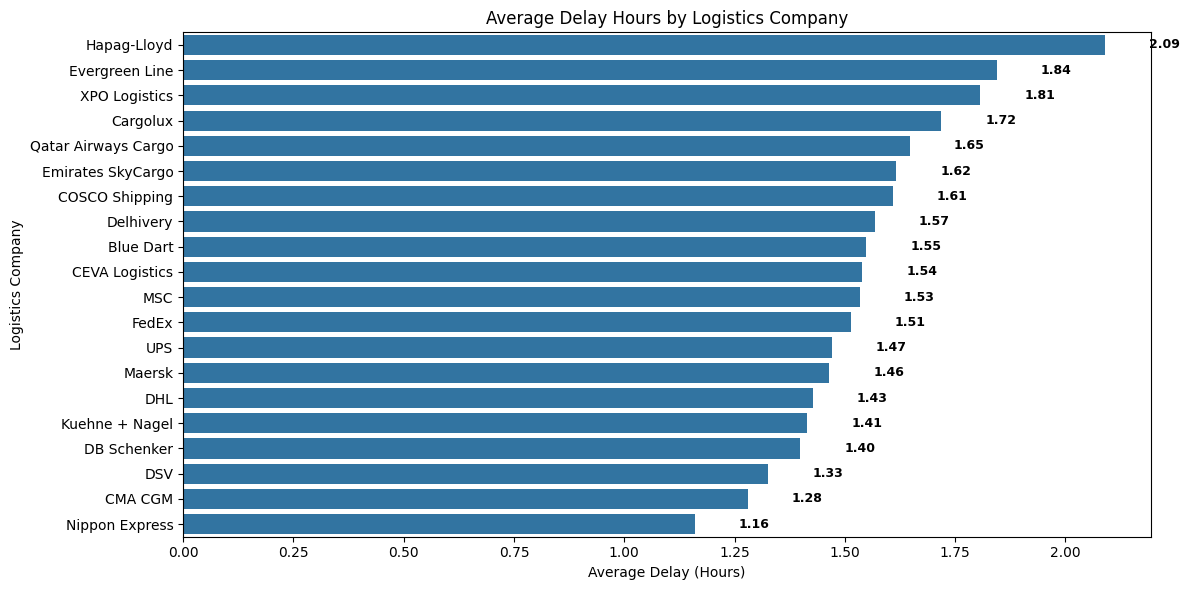

In [ ]:
# ============================================
# AVERAGE DELAY HOURS BY COMPANY
# ============================================

company_avg_delay = (
    df.groupby("Company")["Delay_Hours"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=company_avg_delay.values,
    y=company_avg_delay.index
)

# Display values
for i, value in enumerate(company_avg_delay.values):
    ax.text(
        value + 0.1,
        i,
        f"{value:.2f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Average Delay Hours by Logistics Company")
plt.xlabel("Average Delay (Hours)")
plt.ylabel("Logistics Company")

plt.tight_layout()
plt.show()

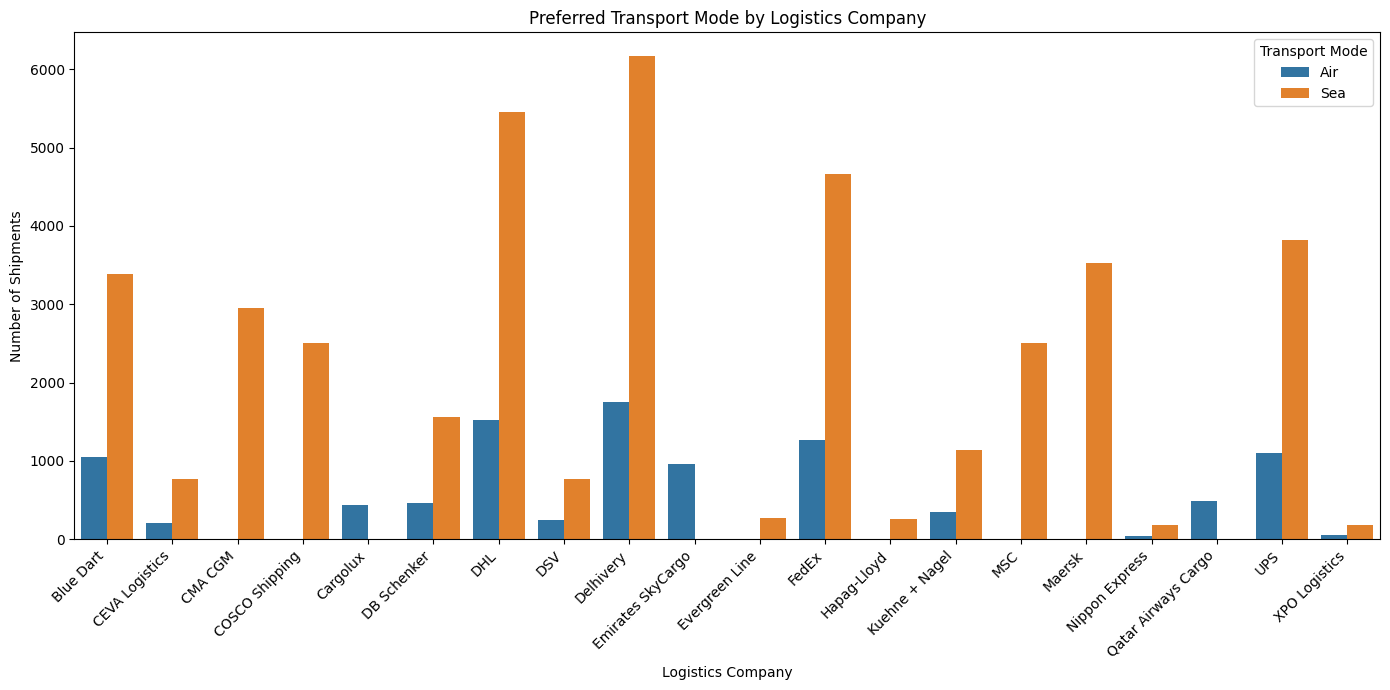

In [ ]:
# ============================================
# PREFERRED TRANSPORT MODE BY COMPANY
# ============================================

company_transport = (
    df.groupby(["Company", "Transport_Mode"])
      .size()
      .reset_index(name="Shipments")
)

plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=company_transport,
    x="Company",
    y="Shipments",
    hue="Transport_Mode"
)

plt.title("Preferred Transport Mode by Logistics Company")
plt.xlabel("Logistics Company")
plt.ylabel("Number of Shipments")

plt.xticks(rotation=45, ha="right")

plt.legend(title="Transport Mode")

plt.tight_layout()
plt.show()

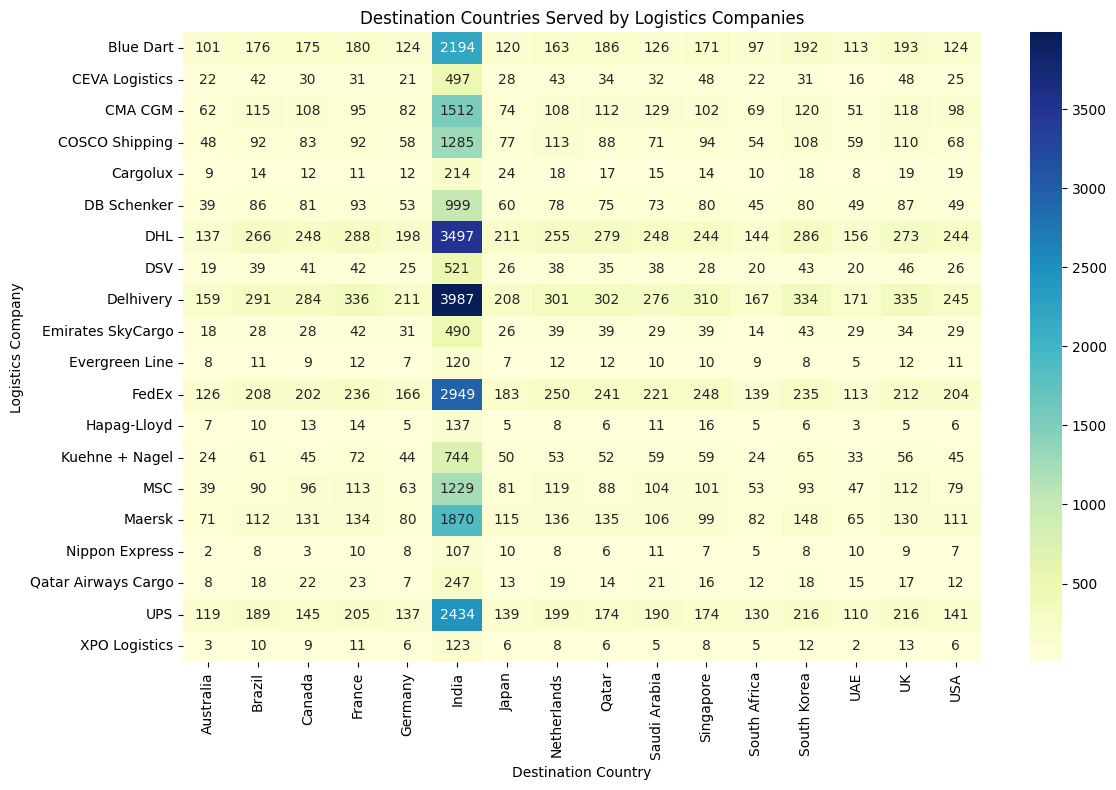

In [ ]:
# ============================================
# DESTINATION COUNTRIES BY COMPANY (Which countries are served most frequently by each logistics company?)
# ============================================

company_country = pd.crosstab(
    df["Company"],
    df["Destination_Country"]
)

plt.figure(figsize=(12,8))

sns.heatmap(
    company_country,
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.title("Destination Countries Served by Logistics Companies")
plt.xlabel("Destination Country")
plt.ylabel("Logistics Company")

plt.tight_layout()
plt.show()

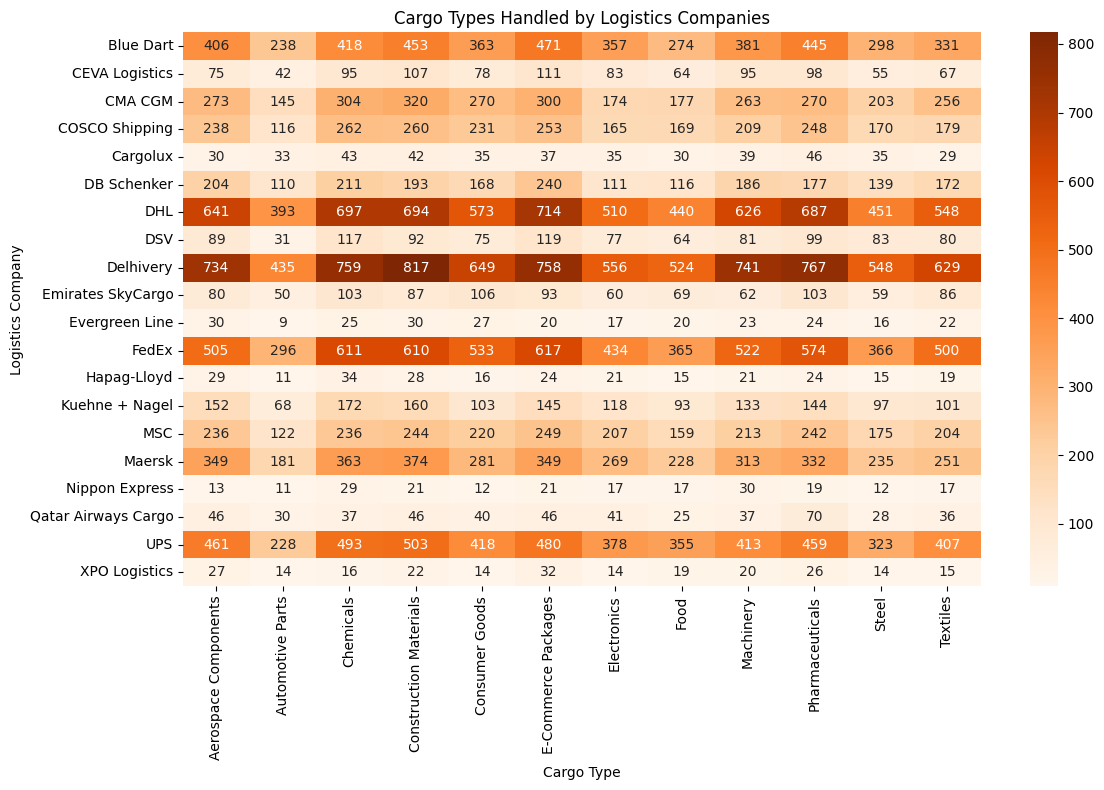

In [ ]:
# ============================================
# CARGO TYPE HANDLED BY COMPANY
# ============================================

company_cargo = pd.crosstab(
    df["Company"],
    df["Cargo_Type"]
)

plt.figure(figsize=(12,8))

sns.heatmap(
    company_cargo,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Cargo Types Handled by Logistics Companies")
plt.xlabel("Cargo Type")
plt.ylabel("Logistics Company")

plt.tight_layout()
plt.show()

In [ ]:
#---------------------------------------------------
####################################################
#{{{{{{{{{{{{{{{{
#Transport Mode Analysis
#}}}}}}}}}}}}}}}}
#---------------------------------------------------
####################################################

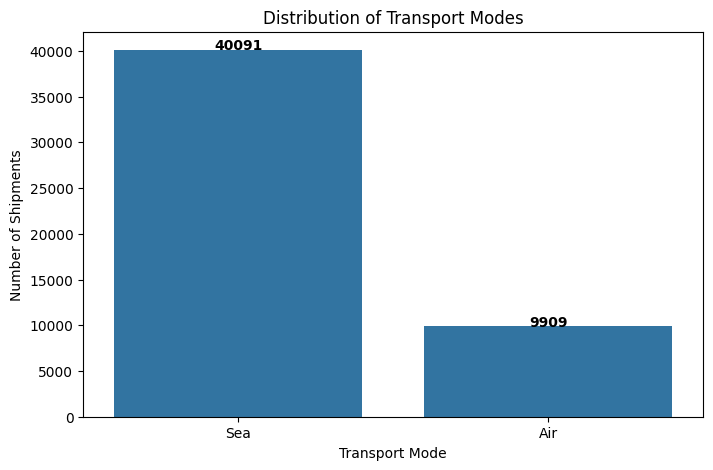

In [ ]:
# ============================================
# TRANSPORT MODE DISTRIBUTION
# ============================================

mode_count = df["Transport_Mode"].value_counts()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=mode_count.index,
    y=mode_count.values
)

# Display values
for i, value in enumerate(mode_count.values):
    ax.text(
        i,
        value + 20,
        str(value),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Distribution of Transport Modes")
plt.xlabel("Transport Mode")
plt.ylabel("Number of Shipments")

plt.show()

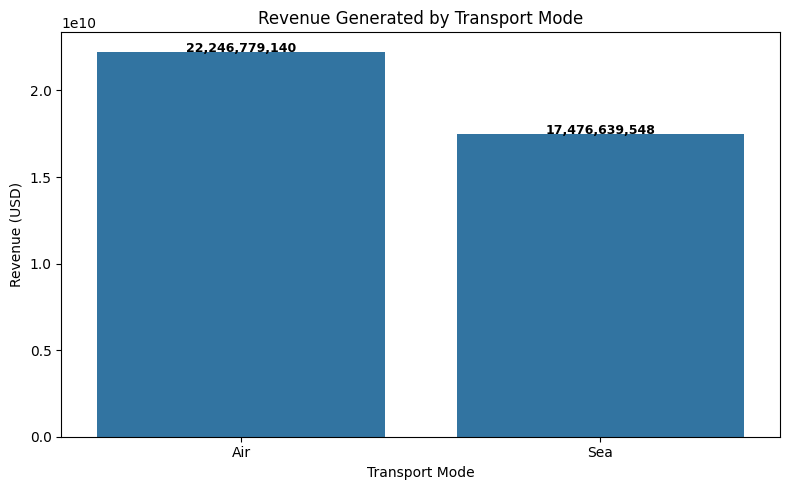

In [ ]:
# ============================================
# REVENUE BY TRANSPORT MODE
# ============================================

mode_revenue = (
    df.groupby("Transport_Mode")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=mode_revenue.index,
    y=mode_revenue.values
)

# Display values
for i, value in enumerate(mode_revenue.values):
    ax.text(
        i,
        value,
        f"{value:,.0f}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Revenue Generated by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Revenue (USD)")

plt.tight_layout()
plt.show()

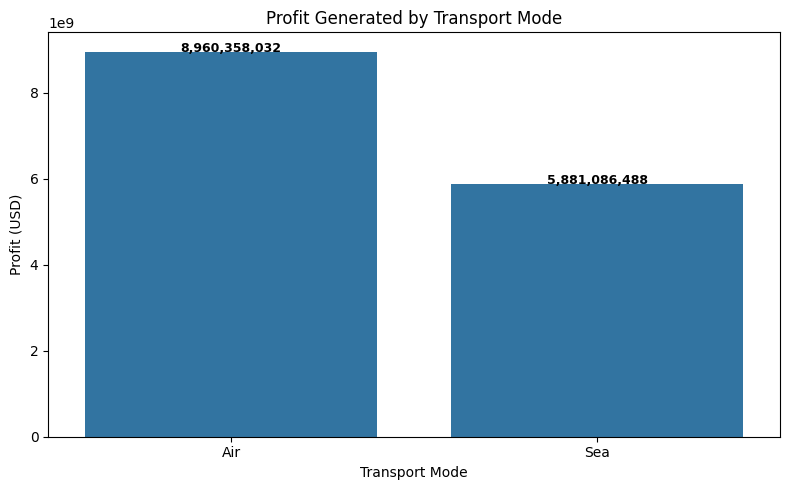

In [ ]:
# ============================================
# PROFIT BY TRANSPORT MODE
# ============================================

mode_profit = (
    df.groupby("Transport_Mode")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=mode_profit.index,
    y=mode_profit.values
)

# Display values
for i, value in enumerate(mode_profit.values):
    ax.text(
        i,
        value,
        f"{value:,.0f}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Profit Generated by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Profit (USD)")

plt.tight_layout()
plt.show()

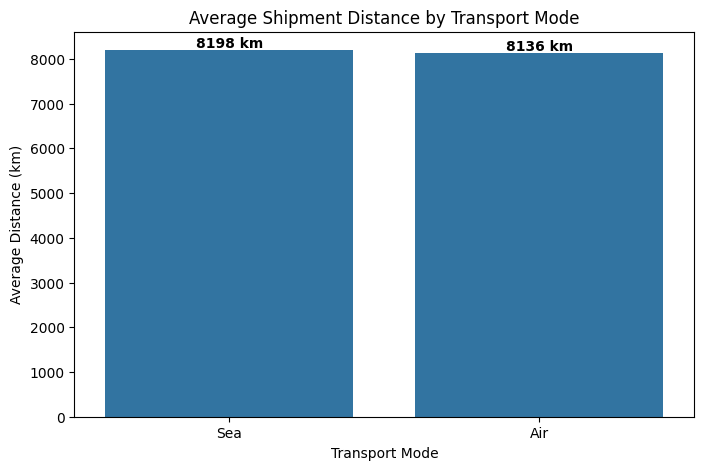

In [ ]:
# ============================================
# AVERAGE DISTANCE BY TRANSPORT MODE
# ============================================

mode_distance = (
    df.groupby("Transport_Mode")["Distance_km"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=mode_distance.index,
    y=mode_distance.values
)

for i, value in enumerate(mode_distance.values):
    ax.text(
        i,
        value + 50,
        f"{value:.0f} km",
        ha="center",
        fontweight="bold"
    )

plt.title("Average Shipment Distance by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Average Distance (km)")

plt.show()

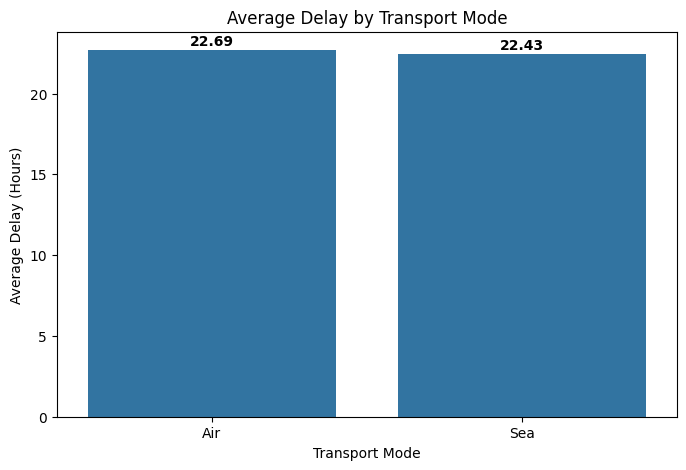

In [ ]:
# ============================================
# AVERAGE DELAY BY TRANSPORT MODE
# ============================================

mode_delay = (
    delayed_shipments.groupby("Transport_Mode")["Delay_Hours"]
                     .mean()
                     .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=mode_delay.index,
    y=mode_delay.values
)

for i, value in enumerate(mode_delay.values):
    ax.text(
        i,
        value + 0.3,
        f"{value:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.title("Average Delay by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Average Delay (Hours)")

plt.show()

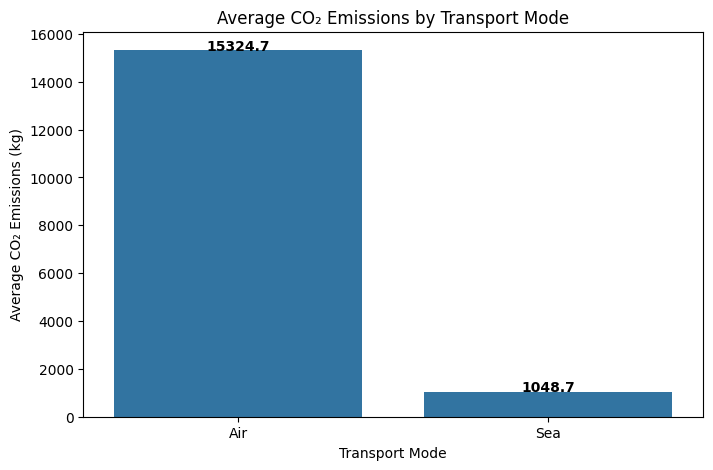

In [ ]:
# ============================================
# CO₂ EMISSIONS BY TRANSPORT MODE
# ============================================

mode_co2 = (
    df.groupby("Transport_Mode")["CO2_kg"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=mode_co2.index,
    y=mode_co2.values
)

for i, value in enumerate(mode_co2.values):
    ax.text(
        i,
        value + 5,
        f"{value:.1f}",
        ha="center",
        fontweight="bold"
    )

plt.title("Average CO₂ Emissions by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Average CO₂ Emissions (kg)")

plt.show()

In [ ]:
#---------------------------------------------------
####################################################
#{{{{{{{{{{{{{{{{
#Destination Analysis
#}}}}}}}}}}}}}}}}
#---------------------------------------------------
####################################################

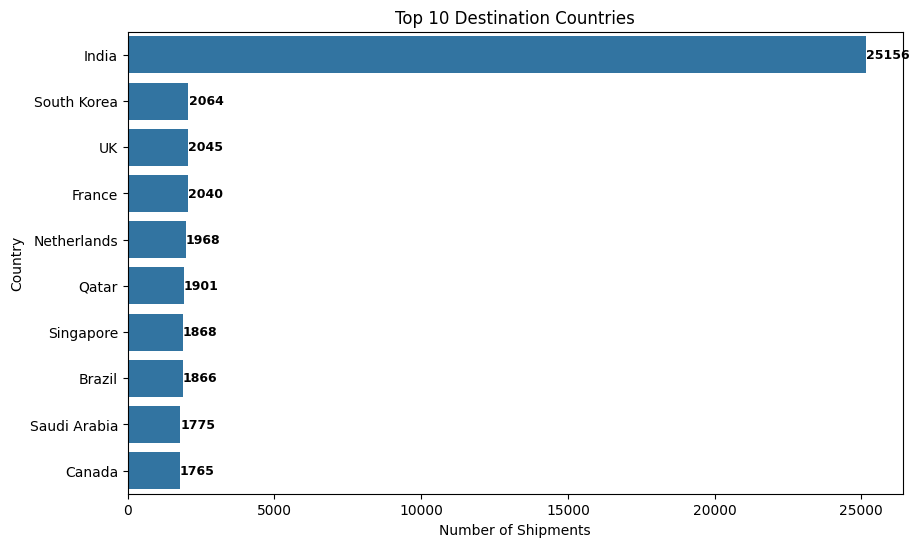

In [ ]:
top_country = (
    df["Destination_Country"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    y=top_country.index,
    x=top_country.values
)

# Add values beside bars
for i, value in enumerate(top_country.values):
    ax.text(
        value + 10,
        i,
        str(value),
        va='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title("Top 10 Destination Countries")
plt.xlabel("Number of Shipments")
plt.ylabel("Country")

plt.show()

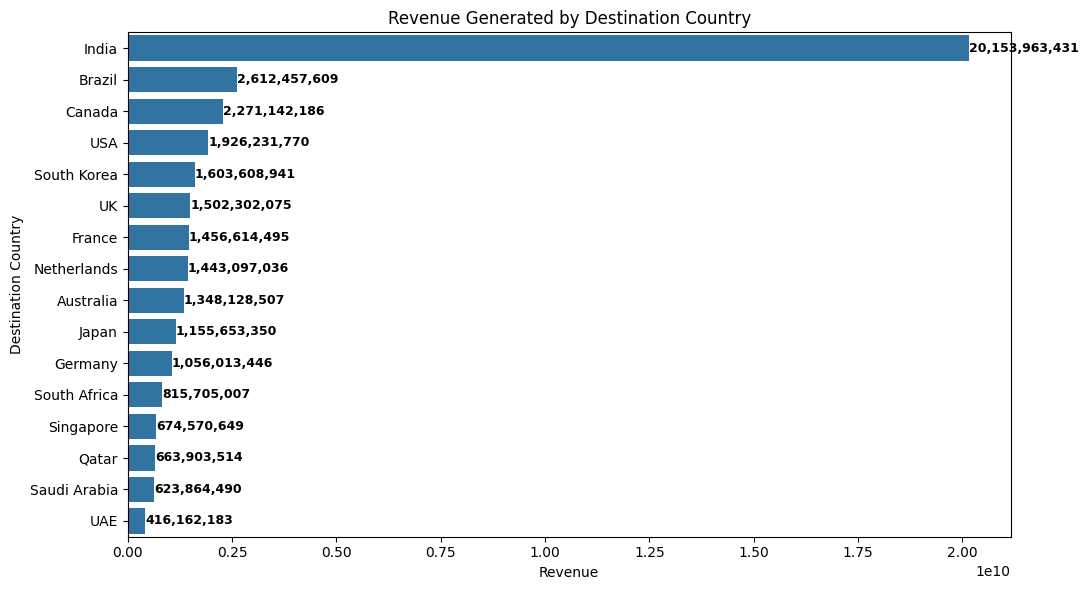

In [ ]:
# ============================================
# REVENUE BY DESTINATION COUNTRY
# ============================================

country_revenue = (
    df.groupby("Destination_Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(11,6))

ax = sns.barplot(
    x=country_revenue.values,
    y=country_revenue.index
)

for i, value in enumerate(country_revenue.values):
    ax.text(
        value,
        i,
        f"{value:,.0f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Revenue Generated by Destination Country")
plt.xlabel("Revenue")
plt.ylabel("Destination Country")

plt.tight_layout()
plt.show()

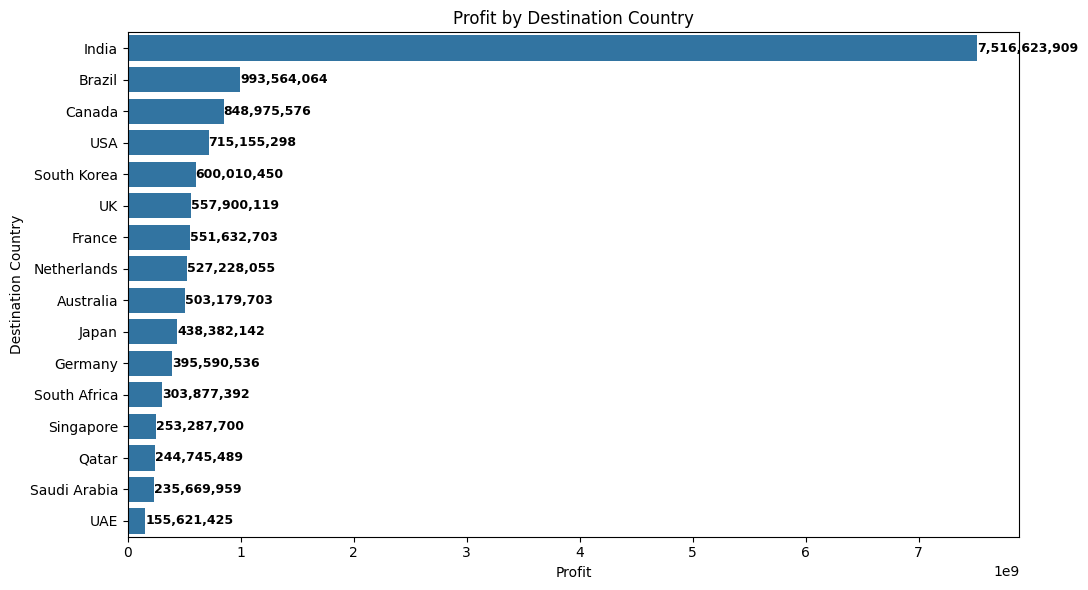

In [ ]:
# ============================================
# PROFIT BY DESTINATION COUNTRY
# ============================================

country_profit = (
    df.groupby("Destination_Country")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(11,6))

ax = sns.barplot(
    x=country_profit.values,
    y=country_profit.index
)

for i, value in enumerate(country_profit.values):
    ax.text(
        value,
        i,
        f"{value:,.0f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Profit by Destination Country")
plt.xlabel("Profit")
plt.ylabel("Destination Country")

plt.tight_layout()
plt.show()

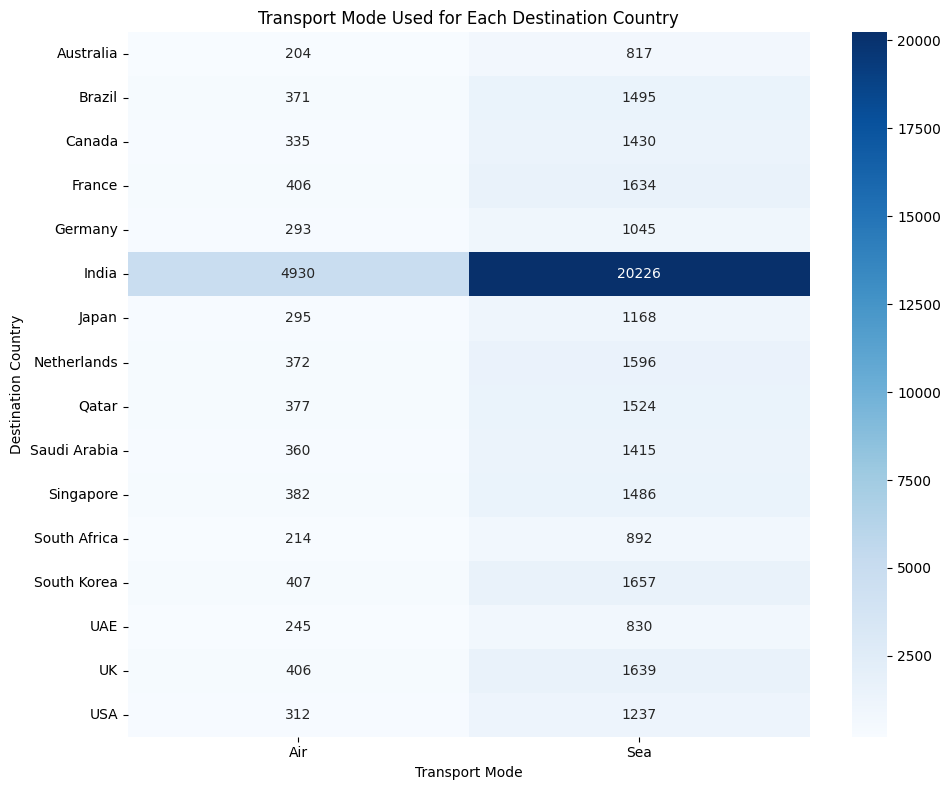

In [ ]:
# ============================================
# TRANSPORT MODE BY DESTINATION COUNTRY
# ============================================

country_transport = pd.crosstab(
    df["Destination_Country"],
    df["Transport_Mode"]
)

plt.figure(figsize=(10,8))

sns.heatmap(
    country_transport,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Transport Mode Used for Each Destination Country")
plt.xlabel("Transport Mode")
plt.ylabel("Destination Country")

plt.tight_layout()
plt.show()

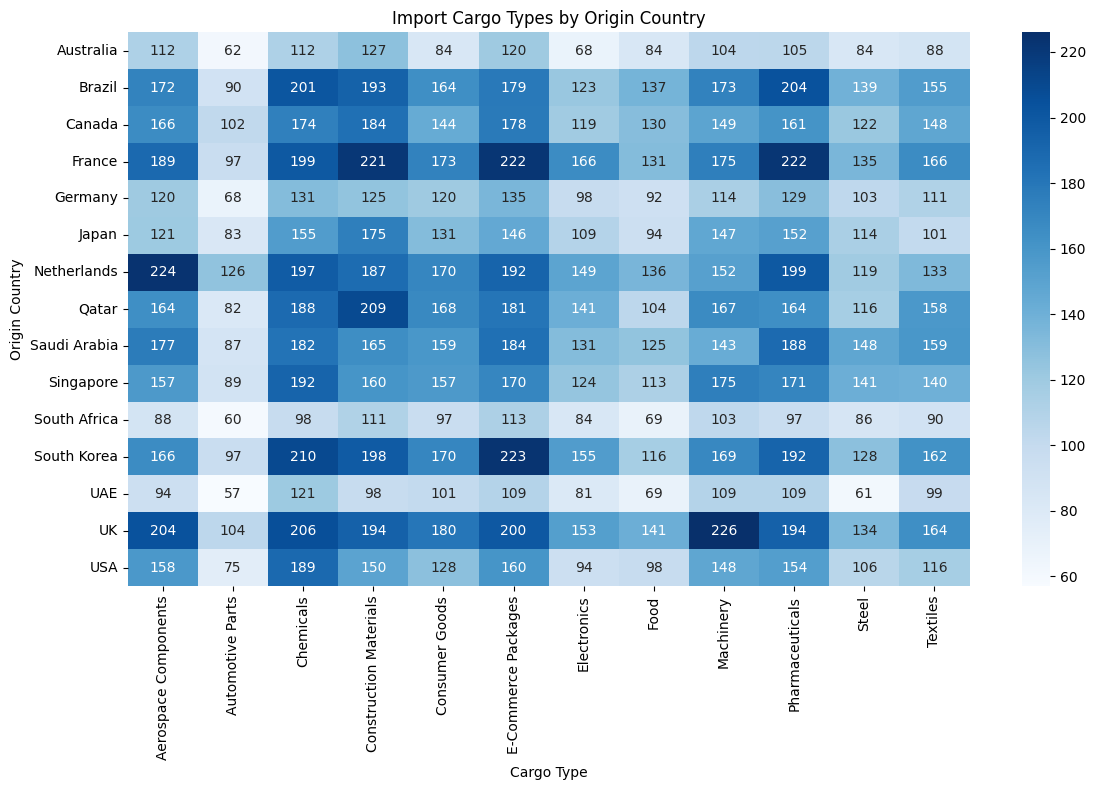

In [ ]:
# ============================================
# IMPORT CARGO BY ORIGIN COUNTRY
# ============================================

import_df = df[df["Trade_Type"] == "Import"]

country_cargo_import = pd.crosstab(
    import_df["Origin_Country"],
    import_df["Cargo_Type"]
)

plt.figure(figsize=(12,8))

sns.heatmap(
    country_cargo_import,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Import Cargo Types by Origin Country")
plt.xlabel("Cargo Type")
plt.ylabel("Origin Country")

plt.tight_layout()

plt.show()

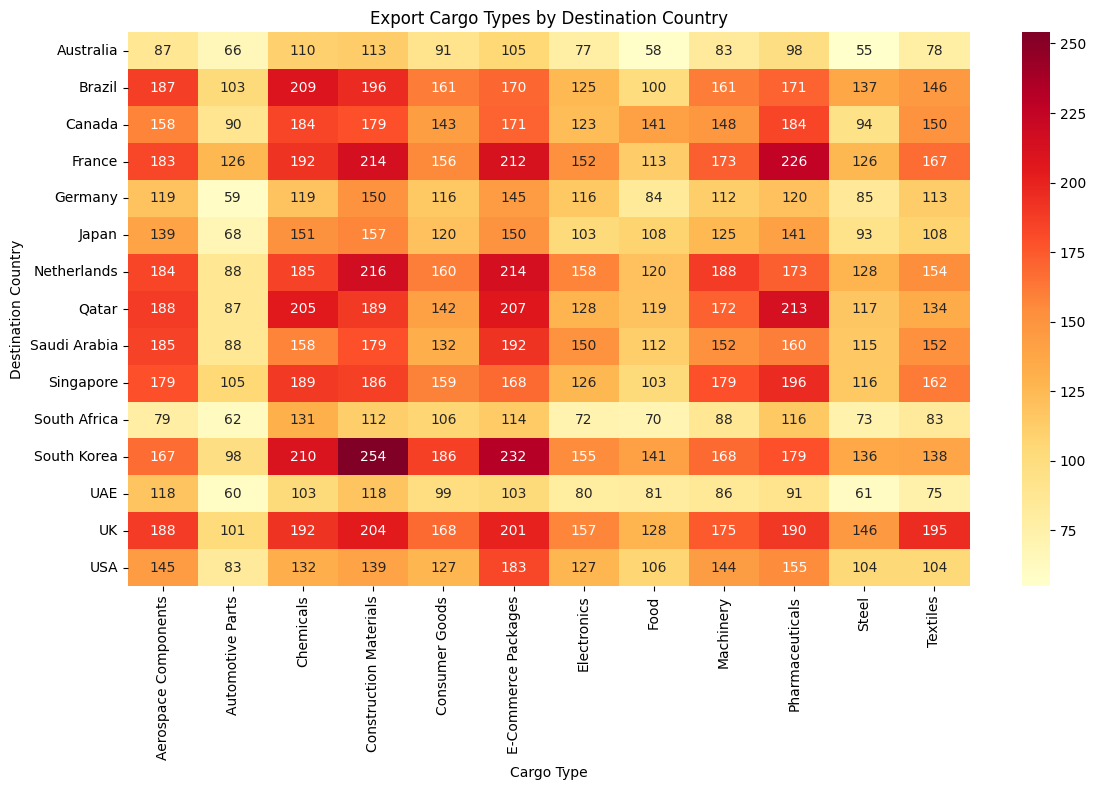

In [ ]:
# ============================================
# EXPORT CARGO BY DESTINATION COUNTRY
# ============================================

export_df = df[df["Trade_Type"] == "Export"]

country_cargo_export = pd.crosstab(
    export_df["Destination_Country"],
    export_df["Cargo_Type"]
)

plt.figure(figsize=(12,8))

sns.heatmap(
    country_cargo_export,
    annot=True,
    fmt="d",
    cmap="YlOrRd"
)

plt.title("Export Cargo Types by Destination Country")
plt.xlabel("Cargo Type")
plt.ylabel("Destination Country")

plt.tight_layout()

plt.show()

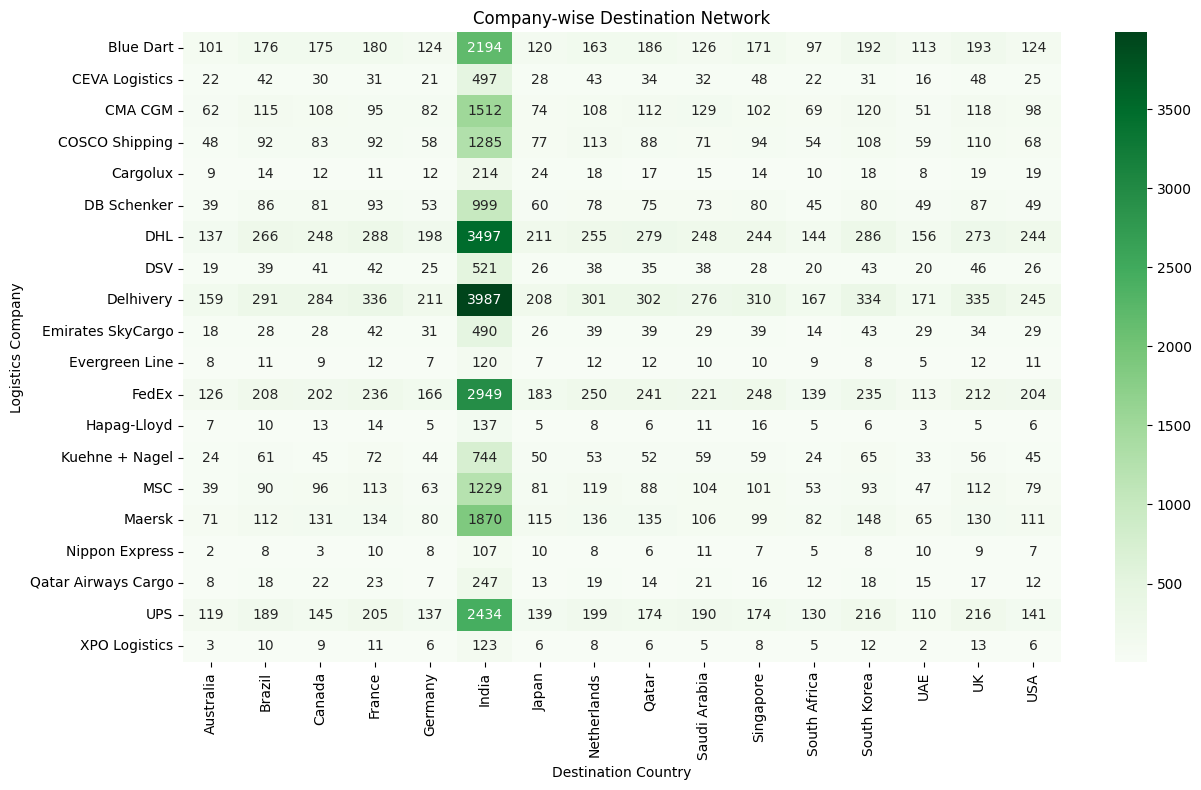

In [ ]:
# ============================================
# COMPANY-WISE DESTINATION NETWORK
# ============================================

company_destination = pd.crosstab(
    df["Company"],
    df["Destination_Country"]
)

plt.figure(figsize=(13,8))

sns.heatmap(
    company_destination,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Company-wise Destination Network")
plt.xlabel("Destination Country")
plt.ylabel("Logistics Company")

plt.tight_layout()
plt.show()

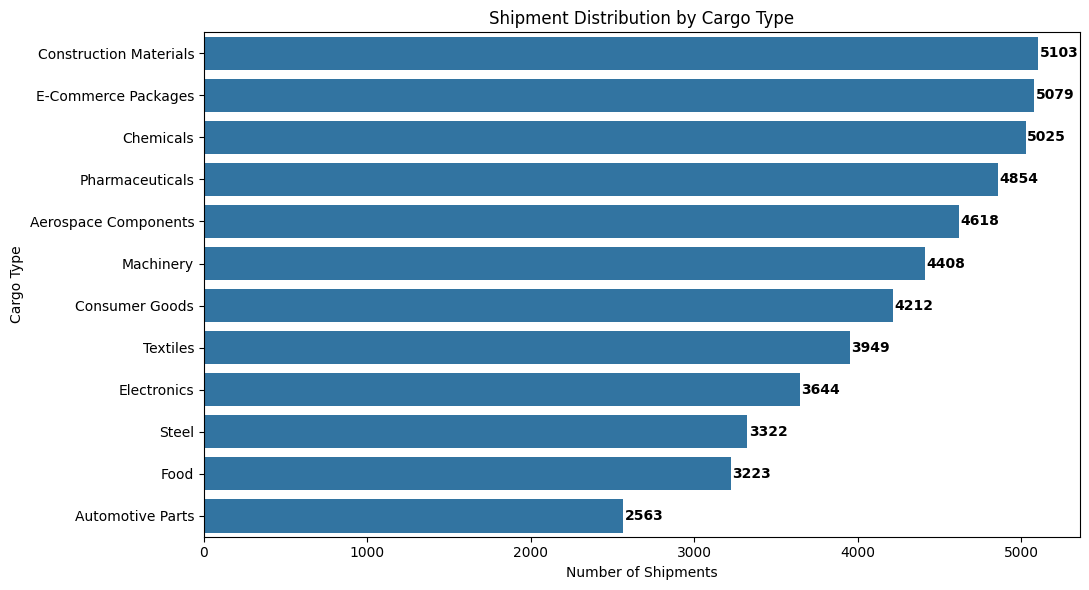

In [ ]:
# ============================================
# CARGO TYPE DISTRIBUTION
# ============================================

cargo_count = df["Cargo_Type"].value_counts()

plt.figure(figsize=(11,6))

ax = sns.barplot(
    x=cargo_count.values,
    y=cargo_count.index
)

for i, value in enumerate(cargo_count.values):
    ax.text(
        value + 10,
        i,
        str(value),
        va="center",
        fontweight="bold"
    )

plt.title("Shipment Distribution by Cargo Type")
plt.xlabel("Number of Shipments")
plt.ylabel("Cargo Type")

plt.tight_layout()
plt.show()

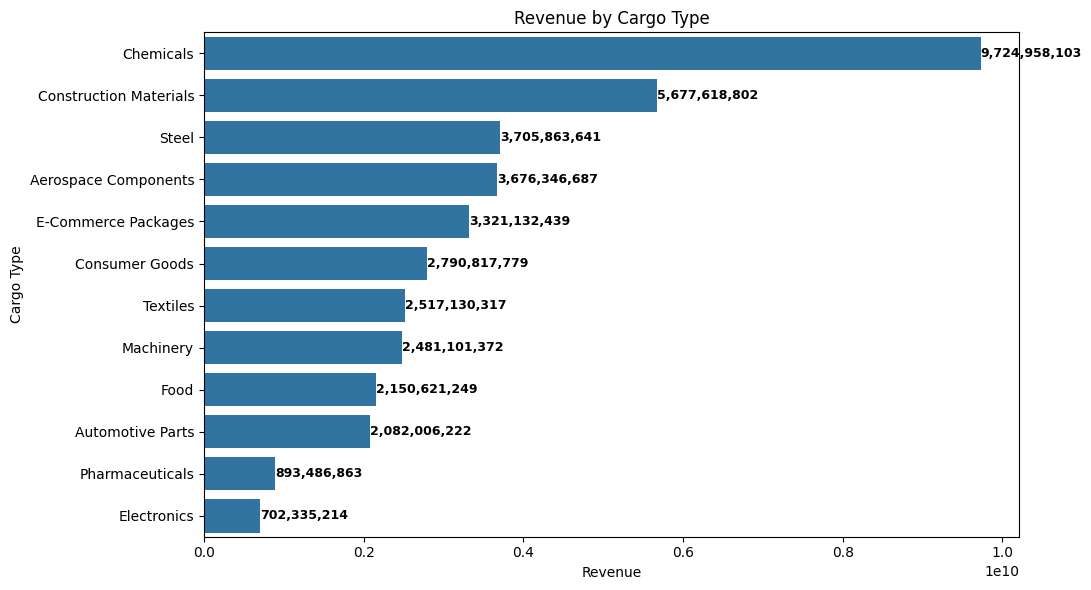

In [ ]:
# ============================================
# REVENUE BY CARGO TYPE
# ============================================

cargo_revenue = (
    df.groupby("Cargo_Type")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(11,6))

ax = sns.barplot(
    x=cargo_revenue.values,
    y=cargo_revenue.index
)

for i, value in enumerate(cargo_revenue.values):
    ax.text(
        value,
        i,
        f"{value:,.0f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Revenue by Cargo Type")
plt.xlabel("Revenue")
plt.ylabel("Cargo Type")

plt.tight_layout()
plt.show()

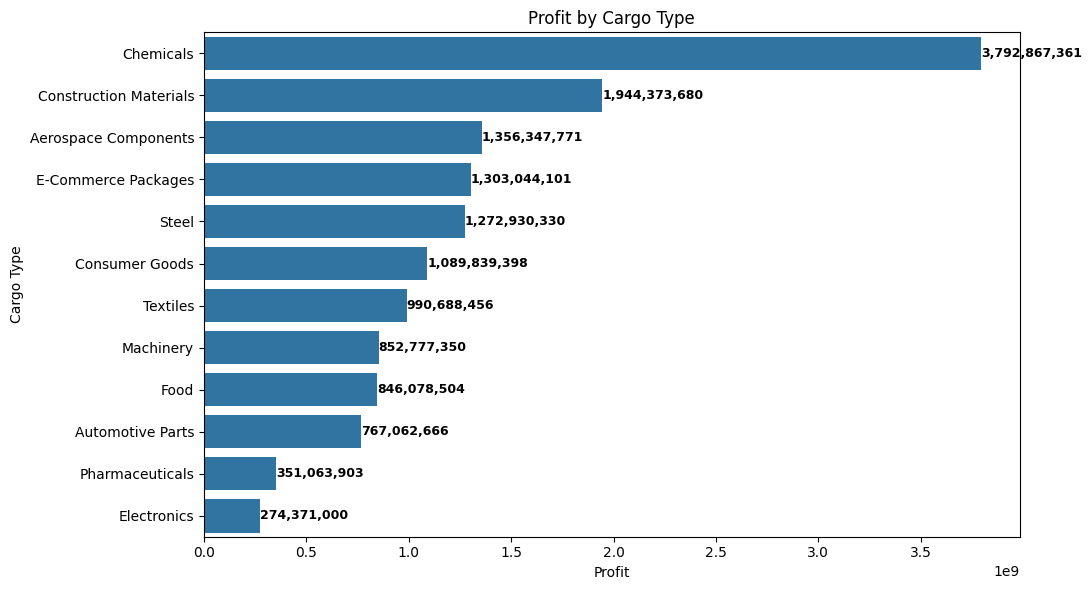

In [ ]:
# ============================================
# PROFIT BY CARGO TYPE
# ============================================

cargo_profit = (
    df.groupby("Cargo_Type")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(11,6))

ax = sns.barplot(
    x=cargo_profit.values,
    y=cargo_profit.index
)

for i, value in enumerate(cargo_profit.values):
    ax.text(
        value,
        i,
        f"{value:,.0f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Profit by Cargo Type")
plt.xlabel("Profit")
plt.ylabel("Cargo Type")

plt.tight_layout()
plt.show()

## **Correlation Analysis**

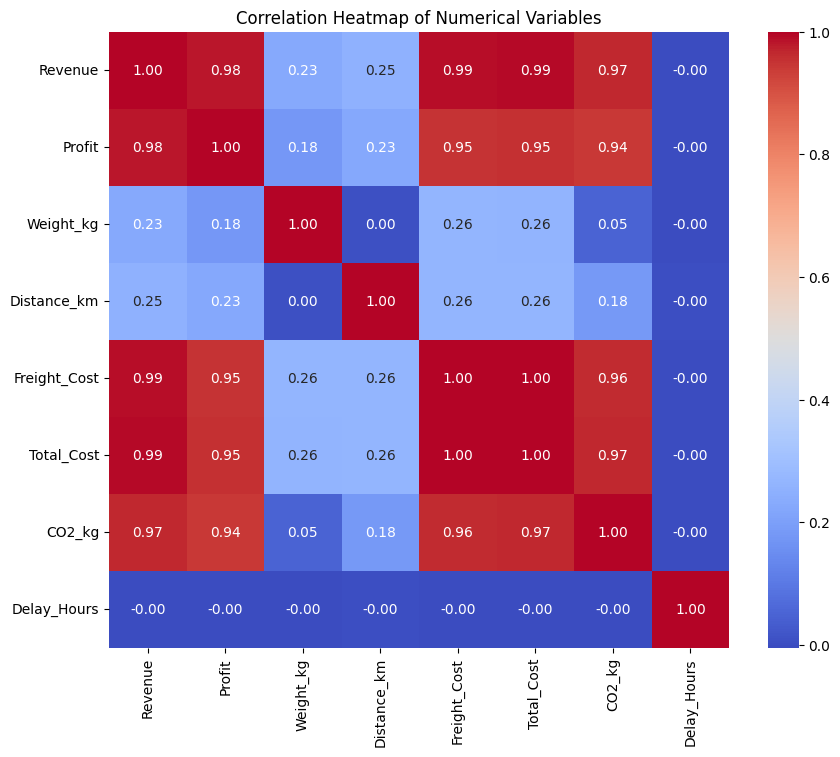

In [ ]:
corr_columns = [
    "Revenue",
    "Profit",
    "Weight_kg",
    "Distance_km",
    "Freight_Cost",
    "Total_Cost",
    "CO2_kg",
    "Delay_Hours"
]

corr_matrix = df[corr_columns].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

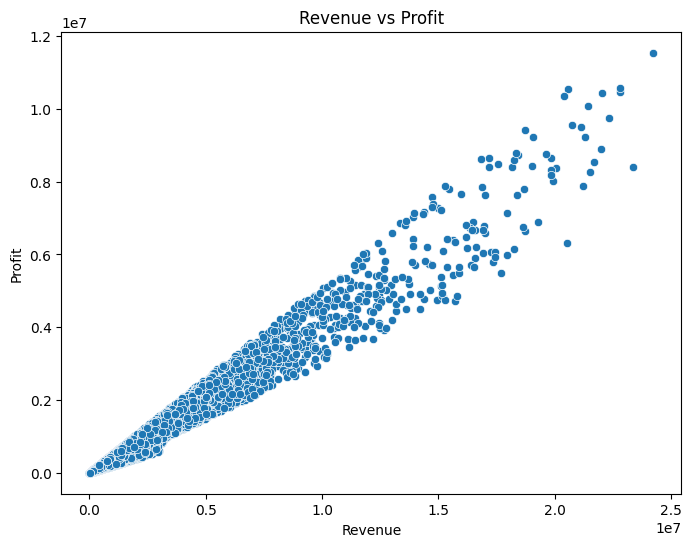

In [ ]:
# ============================================
# REVENUE VS PROFIT
# ============================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Revenue",
    y="Profit"
)

plt.title("Revenue vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")

plt.show()

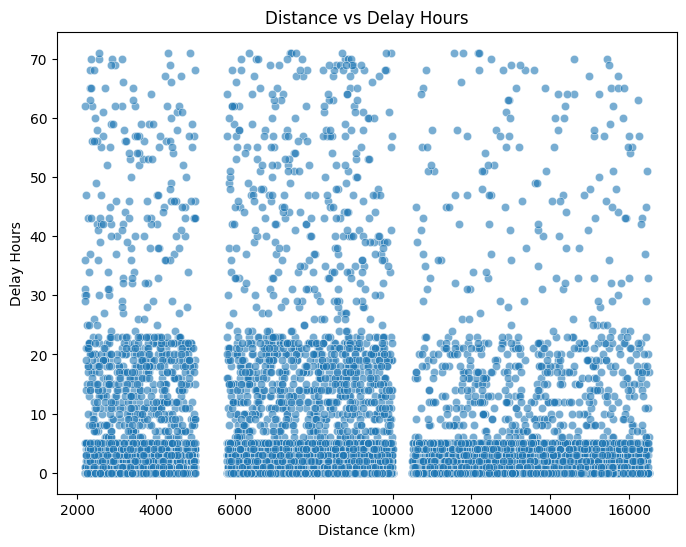

In [ ]:
# ============================================
# DISTANCE VS DELAY HOURS
# ============================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Distance_km",
    y="Delay_Hours",
    alpha=0.6
)

plt.title("Distance vs Delay Hours")
plt.xlabel("Distance (km)")
plt.ylabel("Delay Hours")

plt.show()

# **Final Business Analytics**

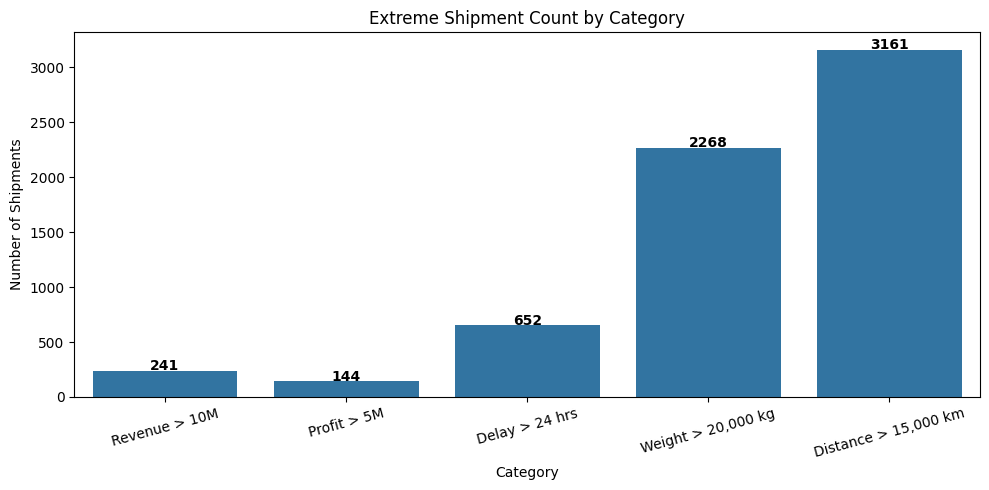

In [ ]:
# ============================================
# EXTREME VALUE COUNT
# ============================================

extreme_counts = {
    "Revenue > 10M": (df["Revenue"] > 10000000).sum(),
    "Profit > 5M": (df["Profit"] > 5000000).sum(),
    "Delay > 24 hrs": (df["Delay_Hours"] > 24).sum(),
    "Weight > 20,000 kg": (df["Weight_kg"] > 20000).sum(),
    "Distance > 15,000 km": (df["Distance_km"] > 15000).sum()
}

extreme_df = pd.DataFrame(
    extreme_counts.items(),
    columns=["Category", "Count"]
)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=extreme_df,
    x="Category",
    y="Count"
)

for i, value in enumerate(extreme_df["Count"]):
    ax.text(i, value + 5, str(value), ha="center", fontweight="bold")

plt.title("Extreme Shipment Count by Category")
plt.xlabel("Category")
plt.ylabel("Number of Shipments")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

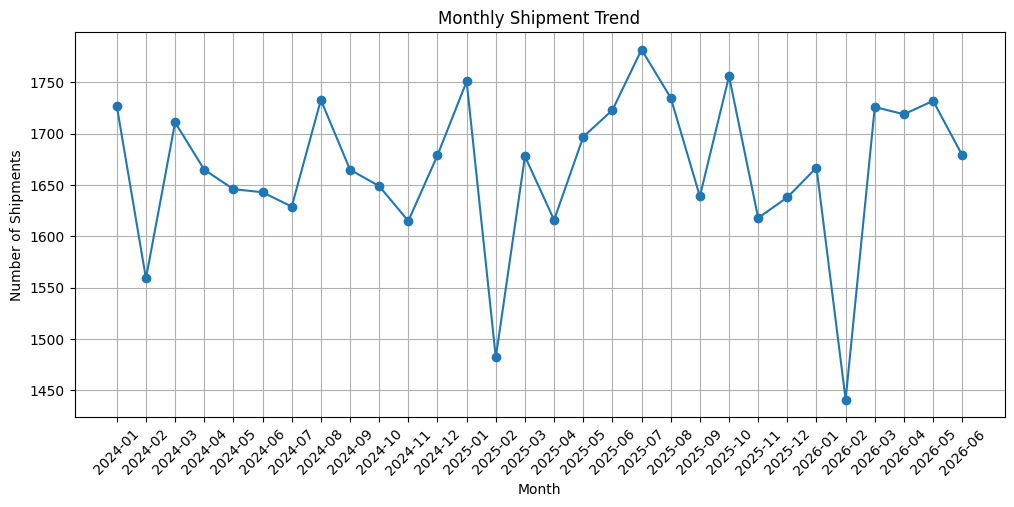

In [ ]:
# ============================================
# MONTHLY SHIPMENT TREND
# ============================================

df["Shipment_Date"] = pd.to_datetime(df["Shipment_Date"])

monthly_shipments = (
    df.groupby(df["Shipment_Date"].dt.to_period("M"))
      .size()
)

monthly_shipments.index = monthly_shipments.index.astype(str)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_shipments.index,
    monthly_shipments.values,
    marker="o"
)

plt.title("Monthly Shipment Trend")
plt.xlabel("Month")
plt.ylabel("Number of Shipments")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

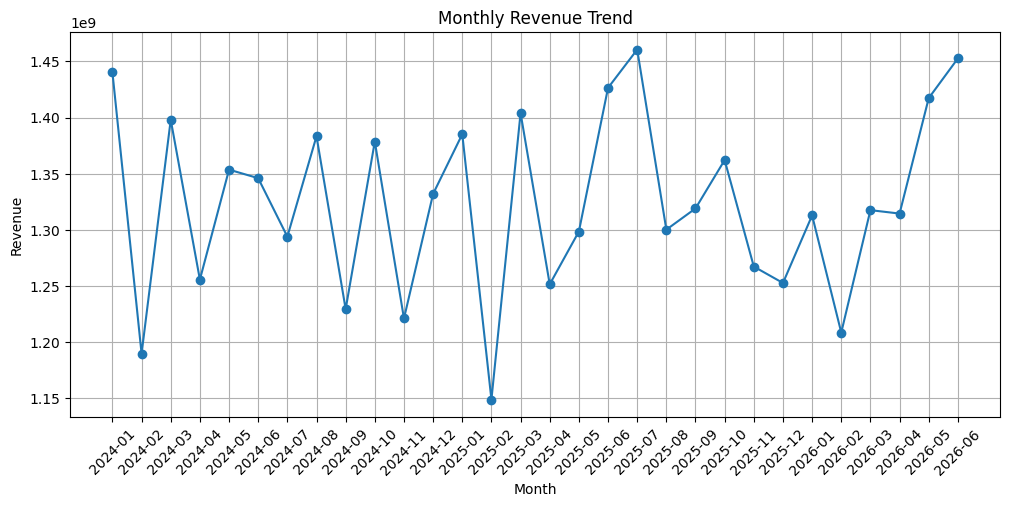

In [ ]:
# ============================================
# MONTHLY REVENUE TREND
# ============================================

monthly_revenue = (
    df.groupby(df["Shipment_Date"].dt.to_period("M"))["Revenue"]
      .sum()
)

monthly_revenue.index = monthly_revenue.index.astype(str)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

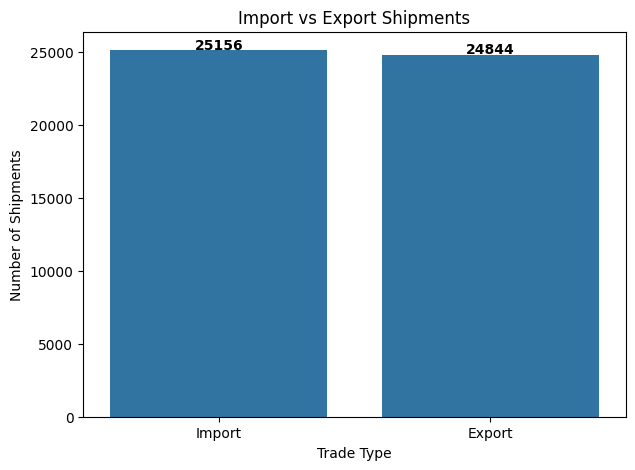

In [ ]:
# ============================================
# IMPORT VS EXPORT
# ============================================

trade_counts = df["Trade_Type"].value_counts()

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=trade_counts.index,
    y=trade_counts.values
)

for i, value in enumerate(trade_counts.values):
    ax.text(i, value + 50, str(value),
            ha="center",
            fontweight="bold")

plt.title("Import vs Export Shipments")
plt.xlabel("Trade Type")
plt.ylabel("Number of Shipments")

plt.show()

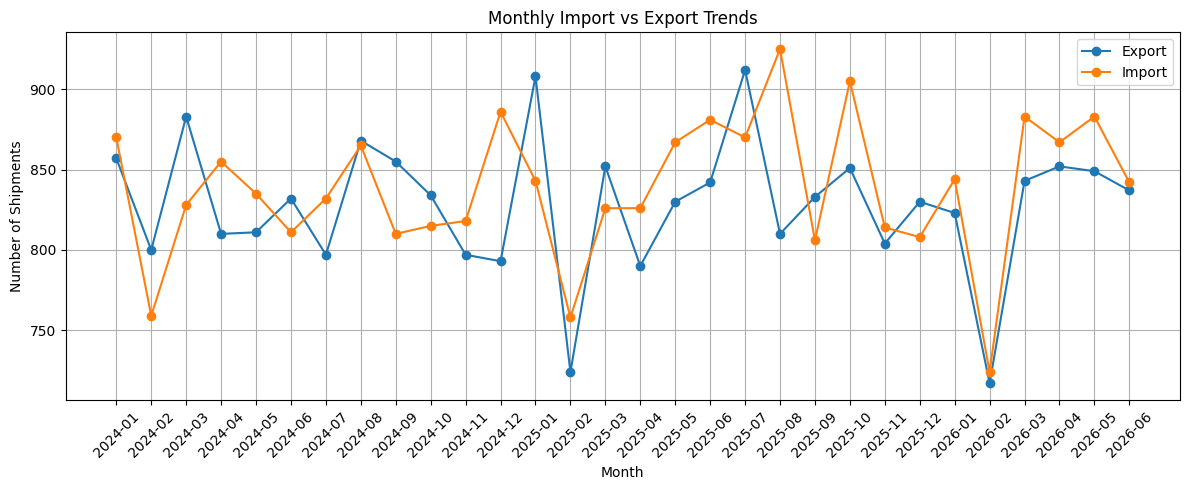

In [ ]:
# ============================================
# IMPORT VS EXPORT TREND
# ============================================

trade_trend = (
    df.groupby([
        df["Shipment_Date"].dt.to_period("M"),
        "Trade_Type"
    ])
    .size()
    .unstack(fill_value=0)
)

trade_trend.index = trade_trend.index.astype(str)

plt.figure(figsize=(12,5))

for trade in trade_trend.columns:
    plt.plot(
        trade_trend.index,
        trade_trend[trade],
        marker="o",
        label=trade
    )

plt.title("Monthly Import vs Export Trends")
plt.xlabel("Month")
plt.ylabel("Number of Shipments")

plt.xticks(rotation=45)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

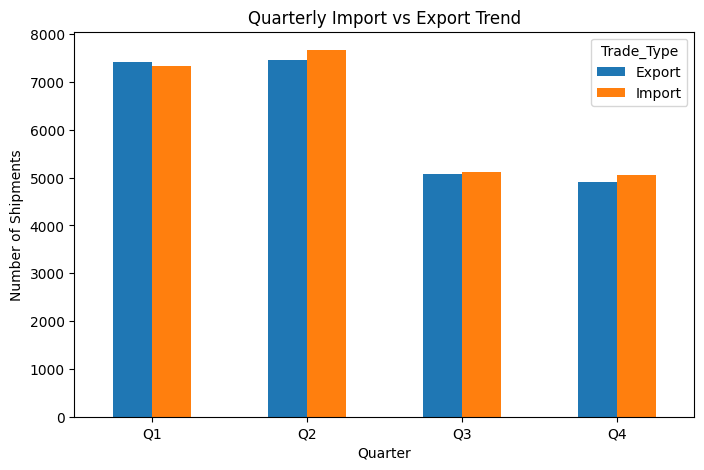

In [ ]:
# ============================================
# QUARTERLY IMPORT VS EXPORT
# ============================================

df["Quarter"] = "Q" + df["Shipment_Date"].dt.quarter.astype(str)

quarter_trade = pd.crosstab(
    df["Quarter"],
    df["Trade_Type"]
)

quarter_trade = quarter_trade.reindex(["Q1","Q2","Q3","Q4"])

quarter_trade.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Quarterly Import vs Export Trend")
plt.xlabel("Quarter")
plt.ylabel("Number of Shipments")

plt.xticks(rotation=0)

plt.show()

In [ ]:
# ============================================
# KPI SUMMARY
# ============================================

total_shipments = len(df)

total_revenue = df["Revenue"].sum()

total_profit = df["Profit"].sum()

average_delay = df["Delay_Hours"].mean()

on_time_rate = (
    (df["Status"] == "Delivered").mean() * 100
)

average_weight = df["Weight_kg"].mean()

average_distance = df["Distance_km"].mean()

companies = df["Company"].nunique()

countries = df["Destination_Country"].nunique()

kpi = pd.DataFrame({
    "Metric":[
        "Total Shipments",
        "Total Revenue",
        "Total Profit",
        "Average Delay (Hours)",
        "On-Time Delivery Rate (%)",
        "Average Shipment Weight (kg)",
        "Average Distance (km)",
        "Logistics Companies",
        "Destination Countries"
    ],
    "Value":[
        total_shipments,
        f"{total_revenue:,.0f}",
        f"{total_profit:,.0f}",
        round(average_delay,2),
        round(on_time_rate,2),
        round(average_weight,2),
        round(average_distance,2),
        companies,
        countries
    ]
})

print(kpi)

                         Metric           Value
0               Total Shipments           50000
1                 Total Revenue  39,723,418,688
2                  Total Profit  14,841,444,519
3         Average Delay (Hours)             1.5
4     On-Time Delivery Rate (%)           84.09
5  Average Shipment Weight (kg)         5590.48
6         Average Distance (km)         8185.65
7           Logistics Companies              20
8         Destination Countries              16


In [ ]:
sorted(df["Company"].unique())

['Blue Dart',
 'CEVA Logistics',
 'CMA CGM',
 'COSCO Shipping',
 'Cargolux',
 'DB Schenker',
 'DHL',
 'DSV',
 'Delhivery',
 'Emirates SkyCargo',
 'Evergreen Line',
 'FedEx',
 'Hapag-Lloyd',
 'Kuehne + Nagel',
 'MSC',
 'Maersk',
 'Nippon Express',
 'Qatar Airways Cargo',
 'UPS',
 'XPO Logistics']

<Figure size 1200x600 with 0 Axes>

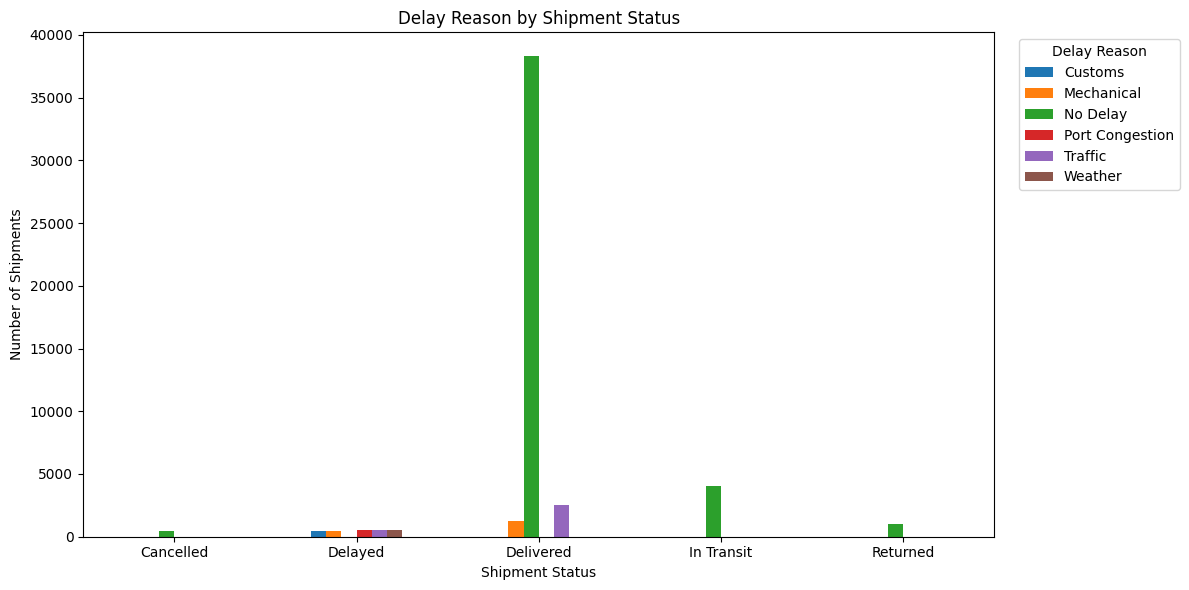

In [ ]:
# ============================================
# DELAY REASON BY SHIPMENT STATUS
# ============================================

plt.figure(figsize=(12,6))

delay_status = pd.crosstab(
    df["Status"],
    df["Delay_Reason"]
)

ax = delay_status.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Delay Reason by Shipment Status")
plt.xlabel("Shipment Status")
plt.ylabel("Number of Shipments")

plt.xticks(rotation=0)

plt.legend(title="Delay Reason", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

plt.show()

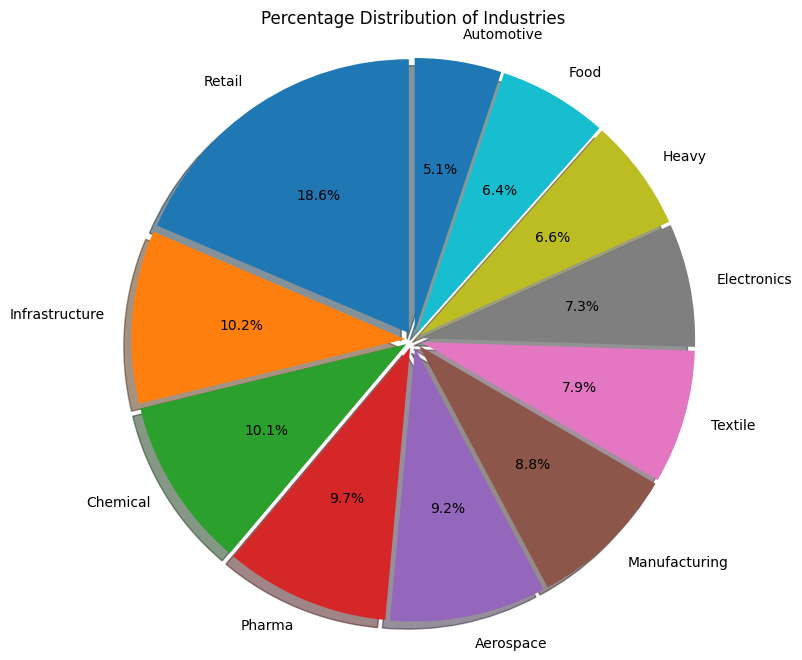

In [ ]:
# ============================================
# PIE CHART - PERCENTAGE DISTRIBUTION
# ============================================

plt.figure(figsize=(8,8))

counts = df["Industry"].value_counts()

plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.03]*len(counts),
    shadow=True
)

plt.title("Percentage Distribution of Industries")

plt.axis("equal")

plt.show()